# Classical Encryption Lab: Building and Breaking Caesar and Substitution Ciphers

**AI for Cybersecurity, Module 2 Lab (2.9)**
**Author:** Ruthvik Nath Bandari

This notebook builds two classical ciphers from scratch, then attacks them the way a cryptanalyst would. The goal is to show *why* one cipher is stronger than the other, and why both are still broken.

| Part | What it covers |
|---|---|
| **0. Setup** | Library imports, reproducible random seed, and a figure output folder |
| **1. Data loading & preprocessing** | The English reference distribution, the test corpus, text normalisation, and input validation |
| **Task 1.1** | Caesar cipher: encrypt, decrypt, and the required test cases |
| **Task 1.2** | Simple substitution cipher: key generation, encrypt, decrypt, and test cases |
| **Task 1.3** | Side-by-side comparison, timing benchmark, and how the ciphertext looks |
| **Task 2.1** | Frequency analysis, a brute-force Caesar breaker, and a frequency attack on substitution |
| **Task 2.2** | Security analysis: brute force, pattern recognition, known plaintext, and frequency |
| **Task 2.3** | Visualisations: frequency chart, all 25 brute-force attempts, comparison table, and pattern analysis |
| **Conclusions** | Findings, limitations, and the link to modern cryptography and AI |

### How this notebook maps to the grading rubric

| Rubric criterion | Where it is addressed |
|---|---|
| Data loading & preprocessing (10) | Section 1: the English frequency table and corpus are loaded and checked (sums, coverage), text is normalised, and edge cases (empty or `None` input, digits, Unicode, bad keys) are validated and tested |
| Detection / attack logic (30) | Task 2.1: a chi-squared scoring rule with a written justification. It is benchmarked against a naive "most common letter = E" rule across 10 message lengths × 300 trials, and there are frequency and known-plaintext attacks on substitution |
| Visualisation (20) | Task 1.3 and 2.3: six labelled figures, each followed by an interpretation |
| Reporting & summary (20) | A markdown interpretation after every result, a security comparison table, and Conclusions |
| Code quality & documentation (20) | Type-hinted functions with docstrings, `assert`-based tests after each component, and a fixed seed so every number reproduces |

## 0. Environment setup

`matplotlib` is the only third-party plotting library. It is pre-installed on Colab, and the `pip` line is kept so the notebook also runs anywhere else. `collections`, `string`, `random`, `time` and `math` are part of the Python standard library, so they need no install, but they are imported explicitly as the brief asks. `pandas` is used only to display tables neatly.

In [1]:
# Colab already ships matplotlib; this line makes the notebook portable to any Jupyter environment.
%pip install -q matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import collections          # Counter for frequency analysis
import string               # ascii_uppercase / ascii_lowercase alphabets
import random               # key generation and random test messages
import time                 # basic timing for the speed comparison
import math                 # factorial / log2 for key-space sizes
import os

import matplotlib.pyplot as plt
import pandas as pd

SEED = 42                   # fixed seed -> every key, table and figure below is reproducible
random.seed(SEED)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

ALPHABET = string.ascii_uppercase   # 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
print("Setup complete. Seed =", SEED)

Setup complete. Seed = 42


## 1. Data loading and preprocessing

A frequency attack needs two inputs:

1. **A reference model of English.** This is the relative frequency of each letter A–Z, taken from Lewand (2000), *Cryptological Mathematics*, which is the standard table used in cryptanalysis teaching.
2. **Test text.** This is a corpus of plain English that we encrypt and then try to break. I wrote the corpus myself, on cybersecurity topics, so the lab uses original material.

Before either is used it is **validated**: the frequencies must cover all 26 letters and sum to about 100%, and the corpus must be long enough to give stable statistics.

In [3]:
# Relative frequency (%) of letters in English text (Lewand, 2000).
ENGLISH_FREQ = {
    'A': 8.167, 'B': 1.492, 'C': 2.782, 'D': 4.253, 'E': 12.702, 'F': 2.228,
    'G': 2.015, 'H': 6.094, 'I': 6.966, 'J': 0.153, 'K': 0.772, 'L': 4.025,
    'M': 2.406, 'N': 6.749, 'O': 7.507, 'P': 1.929, 'Q': 0.095, 'R': 5.987,
    'S': 6.327, 'T': 9.056, 'U': 2.758, 'V': 0.978, 'W': 2.360, 'X': 0.150,
    'Y': 1.974, 'Z': 0.074,
}

# --- validation of the reference data ---------------------------------------
assert set(ENGLISH_FREQ) == set(ALPHABET), "reference table must cover exactly A-Z"
assert all(v > 0 for v in ENGLISH_FREQ.values()), "no letter may have zero probability (chi-squared divides by it)"
total = sum(ENGLISH_FREQ.values())
assert abs(total - 100) < 0.1, f"frequencies should sum to ~100%, got {total}"

# Letters ordered from most to least common: the famous 'ETAOIN SHRDLU' sequence.
ENGLISH_ORDER = "".join(sorted(ENGLISH_FREQ, key=ENGLISH_FREQ.get, reverse=True))
print(f"Reference table OK: 26 letters, sum = {total:.3f}%")
print("English letters by frequency:", ENGLISH_ORDER)

Reference table OK: 26 letters, sum = 99.999%
English letters by frequency: ETAOINSHRDLCUMWFGYPBVKJXQZ


In [4]:
# Original test corpus (written for this lab, five paragraphs). Used for the paragraph-length frequency
# attack and as the source of random messages for the breaker accuracy experiment.
CORPUS = '''
Every organisation that stores data eventually has to decide who is allowed to read it. Encryption
answers that question with mathematics instead of trust. When a message is encrypted, the readable
plaintext is transformed into ciphertext that looks like random noise to anyone without the key. The
strength of the protection depends on two things: how many keys an attacker would need to try, and
whether the ciphertext leaks patterns that let the attacker skip most of that search.

Classical ciphers such as the Caesar shift and the simple substitution cipher were used for centuries
by generals, diplomats and merchants. They are easy to apply with pencil and paper, which made them
practical long before computers existed. Their weakness is that they replace each letter with another
letter in a fixed way. The letter E is still the most common symbol in the ciphertext; it simply wears
a different name. An analyst who counts the symbols can often recover the message without ever
learning the key directly.

Modern security teams face the same idea at a much larger scale. Network traffic, log files and
malware samples all have statistical fingerprints, and defenders use those fingerprints to detect
attacks. The lesson from classical cryptography is that hiding the content of a message is not enough
when the structure of the message remains visible. A strong cipher must destroy that structure, so that
every output looks equally likely no matter what the input was. That principle guides the design of
the algorithms that protect banking, health records and private conversations today.

History offers a clear warning about overconfidence. In the sixteenth century, Mary, Queen of Scots,
trusted a substitution cipher to hide her letters while she was held in captivity. Her messages were
intercepted and handed to a skilled codebreaker named Thomas Phelippes, who counted the symbols, guessed
the most common words, and read the plot against the queen. The cipher had a vast number of possible keys,
yet it failed because the language underneath it was still easy to recognise. The same mistake appears
in software when developers invent their own scrambling scheme and assume that nobody will study it.

A careful defender therefore asks what an attacker can observe, not only what the attacker can guess.
If the length of a message, the timing of a request or the frequency of a word reveals something about
the secret, then the secret is already partly exposed. Good security engineering removes these side
channels wherever possible, relies on public algorithms that have survived years of open review, and
keeps the key as the only thing that must remain hidden. That idea, known as the principle of
Kerckhoffs, is as important for a cloud service today as it was for a telegraph office long ago.
'''.strip()

def normalise_letters(text: str) -> str:
    # Preprocessing for analysis only: keep A-Z, uppercase, drop everything else.
    # (The ciphers themselves never call this; they preserve spaces/punctuation.)
    return "".join(ch for ch in text.upper() if ch in ALPHABET)

corpus_letters = normalise_letters(CORPUS)
print(f"Corpus: {len(CORPUS):,} characters, {len(CORPUS.split()):,} words, {len(corpus_letters):,} letters")
assert len(corpus_letters) > 2000, "need >2000 letters for reliable frequency statistics"

# Sanity check: does our corpus actually look like English? Compare its top letters to the reference.
corpus_top = "".join(l for l, _ in collections.Counter(corpus_letters).most_common(6))
print("Top-6 letters in corpus :", corpus_top, "  (reference: ETAOIN)")

Corpus: 2,816 characters, 462 words, 2,304 letters
Top-6 letters in corpus : ETASRN   (reference: ETAOIN)


**Interpretation.** The reference table passes every check, and the five-paragraph corpus has about 2,300 letters, which is enough for stable counts. Its top six letters (`ETASRN`) share E, T, A and N with the textbook `ETAOIN`, with E and T in first and second place. The small differences (S and R ranking higher than usual) are normal for a single topic-specific text. This mismatch is exactly why the substitution attack in Task 2.1 needs a refinement step after pure rank-matching.

**Handling missing or awkward input.** The cipher functions below validate their inputs instead of failing silently:
- `None` or non-string input raises a clear `TypeError`.
- An empty string returns an empty string.
- Digits, spaces, punctuation and non-ASCII characters (e.g. `é`, emoji) pass through unchanged.
- Caesar shifts of any integer (negative, or ≥ 26) are reduced modulo 26.
- A substitution key must be an exact permutation of the 26 letters, otherwise a `ValueError` is raised.

In [5]:
def _require_text(text) -> str:
    # Shared input guard for every cipher function.
    if not isinstance(text, str):
        raise TypeError(f"text must be a str, got {type(text).__name__}")
    return text

---
## Task 1.1: Caesar cipher

Each letter is shifted forward `k` places in the alphabet, wrapping from Z back to A:

$$E_k(x) = (x + k) \bmod 26 \qquad D_k(y) = (y - k) \bmod 26$$

Upper and lower case are handled separately, so case is preserved. Any character that is not a letter is copied unchanged.

In [6]:
def caesar_shift_char(ch: str, shift: int) -> str:
    # Shift a single character; non-letters are returned unchanged.
    if 'A' <= ch <= 'Z':
        return chr((ord(ch) - ord('A') + shift) % 26 + ord('A'))
    if 'a' <= ch <= 'z':
        return chr((ord(ch) - ord('a') + shift) % 26 + ord('a'))
    return ch


def caesar_encrypt(plaintext: str, shift: int) -> str:
    '''Encrypt text with a Caesar cipher.

    Args:
        plaintext: message to encrypt (any str; non-letters are preserved).
        shift: number of positions to shift. Any int is accepted and reduced mod 26.
    Returns:
        The ciphertext, same length and case pattern as the input.
    '''
    _require_text(plaintext)
    if not isinstance(shift, int):
        raise TypeError("shift must be an int")
    shift %= 26
    return "".join(caesar_shift_char(ch, shift) for ch in plaintext)


def caesar_decrypt(ciphertext: str, shift: int) -> str:
    '''Decrypt a Caesar ciphertext: decryption is encryption with the negative shift.'''
    return caesar_encrypt(ciphertext, -shift)

In [7]:
long_sentence = ("Security teams in Boston analysed 3,482 suspicious log-ins on Friday, "
                 "and every alert was reviewed before midnight!")

caesar_tests = [
    ("Hello World",        3),
    ("Python Programming", 13),
    (long_sentence,        7),
]

rows = []
for msg, k in caesar_tests:
    ct = caesar_encrypt(msg, k)
    pt = caesar_decrypt(ct, k)
    rows.append({"Shift": k, "Plaintext": msg, "Ciphertext": ct, "Decrypted": pt, "Round-trip OK": pt == msg})
    assert pt == msg, f"round-trip failed for {msg!r}"

# Required check from the brief:
assert caesar_encrypt("Hello World", 3) == "Khoor Zruog"
# ROT13 is its own inverse: applying it twice returns the original.
assert caesar_encrypt(caesar_encrypt("Python Programming", 13), 13) == "Python Programming"

pd.DataFrame(rows)

,Shift,Plaintext,Ciphertext,Decrypted,Round-trip OK
0,3,Hello World,Khoor Zruog,Hello World,True
1,13,Python Programming,Clguba Cebtenzzvat,Python Programming,True
2,7,"Security teams in Boston analysed 3,482 suspicious log-ins on Friday, and every alert was reviewed before midnight!","Zljbypaf alhtz pu Ivzavu huhsfzlk 3,482 zbzwpjpvbz svn-puz vu Mypkhf, huk lclyf hslya dhz ylcpldlk ilmvyl tpkupnoa!","Security teams in Boston analysed 3,482 suspicious log-ins on Friday, and every alert was reviewed before midnight!",True


In [8]:
# Edge-case tests: validation and preservation behaviour.
assert caesar_encrypt("", 5) == ""                                   # empty input
assert caesar_encrypt("abc XYZ", 29) == caesar_encrypt("abc XYZ", 3)  # shift > 26 wraps
assert caesar_encrypt("abc", -1) == "zab"                             # negative shift
assert caesar_encrypt("Café 123 🙂!", 1) == "Dbgé 123 🙂!"            # non-ASCII, digits, emoji preserved
assert caesar_encrypt("Zz", 1) == "Aa"                               # wrap-around keeps case
for bad in (None, 123, ["a"]):
    try:
        caesar_encrypt(bad, 3)
        raise AssertionError("expected TypeError")
    except TypeError:
        pass
print("All Caesar edge-case tests passed.")

All Caesar edge-case tests passed.


**Result.** `"Hello World"` with shift 3 gives **`Khoor Zruog`**, exactly as the brief requires. `"Python Programming"` with shift 13 (ROT13) gives `Clguba Cebtenzzvat`. All three messages decrypt back to the original, and every edge case (empty input, wrap-around, negative shifts, Unicode, and invalid types) behaves as specified.

---
## Task 1.2: Simple substitution cipher

The key is a **random permutation of the alphabet**: each plaintext letter maps to a single ciphertext letter (e.g. A→Q, B→W…). Decryption uses the inverse mapping. The key is generated with `random.shuffle` from the fixed seed, so it can be reproduced.

> Note: Python's `random` module is fine for a lab, but it is **not** cryptographically secure. A real system would draw keys from `secrets.SystemRandom()`.

In [9]:
def generate_substitution_key(rng: random.Random | None = None) -> dict[str, str]:
    # Return a random plaintext->ciphertext mapping over A-Z.
    rng = rng or random
    shuffled = list(ALPHABET)
    rng.shuffle(shuffled)
    return dict(zip(ALPHABET, shuffled))


def validate_key(key: dict[str, str]) -> None:
    # A valid key is a bijection A-Z -> A-Z; anything else would make decryption ambiguous.
    if set(key) != set(ALPHABET) or set(key.values()) != set(ALPHABET):
        raise ValueError("substitution key must map A-Z onto a permutation of A-Z")


def invert_key(key: dict[str, str]) -> dict[str, str]:
    return {c: p for p, c in key.items()}


def substitution_apply(text: str, key: dict[str, str]) -> str:
    # Apply an uppercase mapping to text, preserving case and non-letters.
    out = []
    for ch in text:
        up = ch.upper()
        if up in key:
            sub = key[up]
            out.append(sub if ch.isupper() else sub.lower())
        else:
            out.append(ch)               # spaces, digits, punctuation, Unicode pass through
    return "".join(out)


def substitution_encrypt(plaintext: str, key: dict[str, str]) -> str:
    '''Encrypt with a monoalphabetic substitution key (dict A-Z -> permutation of A-Z).'''
    _require_text(plaintext)
    validate_key(key)
    return substitution_apply(plaintext, key)


def substitution_decrypt(ciphertext: str, key: dict[str, str]) -> str:
    '''Decrypt by applying the inverse of the encryption key.'''
    _require_text(ciphertext)
    validate_key(key)
    return substitution_apply(ciphertext, invert_key(key))

In [10]:
SUB_KEY = generate_substitution_key(random.Random(SEED))

# Show the key used for all substitution tests.
print("Substitution key (plain -> cipher):")
print("Plain : " + " ".join(SUB_KEY.keys()))
print("Cipher: " + " ".join(SUB_KEY.values()))

Substitution key (plain -> cipher):
Plain : A B C D E F G H I J K L M N O P Q R S T U V W X Y Z
Cipher: Q M J Z T G F K P W L S B O X N C R Y E V H I A D U


In [11]:
sub_tests = ["Cybersecurity is important", "Secret Message 123", long_sentence]

rows = []
for msg in sub_tests:
    ct = substitution_encrypt(msg, SUB_KEY)
    pt = substitution_decrypt(ct, SUB_KEY)
    rows.append({"Plaintext": msg, "Ciphertext": ct, "Decrypted": pt, "Round-trip OK": pt == msg})
    assert pt == msg

# Edge cases
assert substitution_encrypt("", SUB_KEY) == ""
assert substitution_encrypt("123 !?", SUB_KEY) == "123 !?"
bad_key = dict(SUB_KEY); bad_key['A'] = bad_key['B']           # two letters -> same output
try:
    substitution_encrypt("abc", bad_key)
    raise AssertionError("expected ValueError")
except ValueError:
    pass
print("All substitution tests passed.")
pd.DataFrame(rows)

All substitution tests passed.


,Plaintext,Ciphertext,Decrypted,Round-trip OK
0,Cybersecurity is important,Jdmtrytjvrped py pbnxreqoe,Cybersecurity is important,True
1,Secret Message 123,Ytjrte Btyyqft 123,Secret Message 123,True
2,"Security teams in Boston analysed 3,482 suspicious log-ins on Friday, and every alert was reviewed before midnight!","Ytjvrped etqby po Mxyexo qoqsdytz 3,482 yvynpjpxvy sxf-poy xo Grpzqd, qoz thtrd qstre iqy rthptitz mtgxrt bpzopfke!","Security teams in Boston analysed 3,482 suspicious log-ins on Friday, and every alert was reviewed before midnight!",True


**Result.** Both required messages encrypt and decrypt correctly. In `"Secret Message 123"` the digits `123` and the space pass through untouched, while the letters are scrambled. Case is kept: capital `S` and `M` stay capitalised. A key that is not a permutation is rejected, because two plaintext letters sharing one ciphertext letter would make decryption impossible.

### Try it yourself

Change `MY_MESSAGE`, `MY_SHIFT` or `MY_KEY_SEED` and re-run this cell to encrypt your own text with any key.

In [12]:
MY_MESSAGE  = "Meet me at the library at 7pm!"   # any text
MY_SHIFT    = 5                                   # any integer Caesar key
MY_KEY_SEED = 2026                                # any integer -> a different random substitution key

my_key = generate_substitution_key(random.Random(MY_KEY_SEED))
c_ct = caesar_encrypt(MY_MESSAGE, MY_SHIFT)
s_ct = substitution_encrypt(MY_MESSAGE, my_key)
print(f"Caesar (shift {MY_SHIFT}) : {c_ct}  ->  {caesar_decrypt(c_ct, MY_SHIFT)}")
print(f"Substitution      : {s_ct}  ->  {substitution_decrypt(s_ct, my_key)}")
print("Key used          :", "".join(my_key.values()))

Caesar (shift 5) : Rjjy rj fy ymj qngwfwd fy 7ur!  ->  Meet me at the library at 7pm!
Substitution      : Jwwh jw mh htw byinmnk mh 7oj!  ->  Meet me at the library at 7pm!
Key used          : MIGCWFSTYELBJAVOPNRHZUXQKD


---
## Task 1.3: Encryption comparison

### 1.3a The same message under both ciphers

In [13]:
compare_msgs = [
    "Attack at dawn",
    "Cybersecurity is important",
    "The password is the password",                 # deliberately repeats a word
    "Meet me at the east gate at noon",
]
CAESAR_KEY = 3
rows = []
for m in compare_msgs:
    rows.append({"Plaintext": m,
                 f"Caesar (shift {CAESAR_KEY})": caesar_encrypt(m, CAESAR_KEY),
                 "Substitution": substitution_encrypt(m, SUB_KEY)})
side_by_side = pd.DataFrame(rows)
side_by_side

,Plaintext,Caesar (shift 3),Substitution
0,Attack at dawn,Dwwdfn dw gdzq,Qeeqjl qe zqio
1,Cybersecurity is important,Fbehuvhfxulwb lv lpsruwdqw,Jdmtrytjvrped py pbnxreqoe
2,The password is the password,Wkh sdvvzrug lv wkh sdvvzrug,Ekt nqyyixrz py ekt nqyyixrz
3,Meet me at the east gate at noon,Phhw ph dw wkh hdvw jdwh dw qrrq,Btte bt qe ekt tqye fqet qe oxxo


**What the ciphertexts show.**
- **Caesar** output looks "orderly": every letter moves by the same amount, so `A→D`, `T→W` everywhere. Once you spot the offset of one letter, you have every letter.
- **Substitution** output looks more random, because neighbouring letters no longer keep their alphabet spacing. But the **word lengths, spaces and repeated words survive in both**. In "The password is the password" the two copies of *password* encrypt to identical ciphertext under both ciphers. This is the first sign of a pattern leak.

### 1.3b Speed benchmark across message lengths
Both ciphers are implemented with the same per-character loop, which makes the timing comparison fair. Each measurement is the **best of 5 repeats**, to reduce noise from other processes.

In [14]:
def best_time(fn, *args, repeats: int = 5) -> float:
    # Return the fastest of `repeats` runs in seconds (min is the standard low-noise estimator).
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(*args)
        best = min(best, time.perf_counter() - t0)
    return best

rng = random.Random(SEED)
lengths = [10, 100, 1_000, 10_000, 100_000]
timing_rows = []
for n in lengths:
    msg = "".join(rng.choice(string.ascii_letters + "   ,.") for _ in range(n))
    c_ct, s_ct = caesar_encrypt(msg, 3), substitution_encrypt(msg, SUB_KEY)
    assert caesar_decrypt(c_ct, 3) == msg and substitution_decrypt(s_ct, SUB_KEY) == msg
    timing_rows.append({
        "Length (chars)": n,
        "Caesar enc (ms)": best_time(caesar_encrypt, msg, 3) * 1e3,
        "Caesar dec (ms)": best_time(caesar_decrypt, c_ct, 3) * 1e3,
        "Subst enc (ms)":  best_time(substitution_encrypt, msg, SUB_KEY) * 1e3,
        "Subst dec (ms)":  best_time(substitution_decrypt, s_ct, SUB_KEY) * 1e3,
    })
timing = pd.DataFrame(timing_rows)
timing["Caesar µs/char"] = timing["Caesar enc (ms)"] * 1e3 / timing["Length (chars)"]
timing["Subst µs/char"]  = timing["Subst enc (ms)"]  * 1e3 / timing["Length (chars)"]
timing.round(4)

,Length (chars),Caesar enc (ms),Caesar dec (ms),Subst enc (ms),Subst dec (ms),Caesar µs/char,Subst µs/char
0,10,0.0020,0.0015,0.0026,0.0033,0.1958,0.2583
1,100,0.0117,0.0117,0.0097,0.0107,0.1167,0.0971
2,1000,0.0988,0.1067,0.0730,0.0703,0.0988,0.0730
3,10000,1.0690,1.0631,0.7158,0.6964,0.1069,0.0716
4,100000,10.7397,10.8259,7.0942,7.1348,0.1074,0.0709


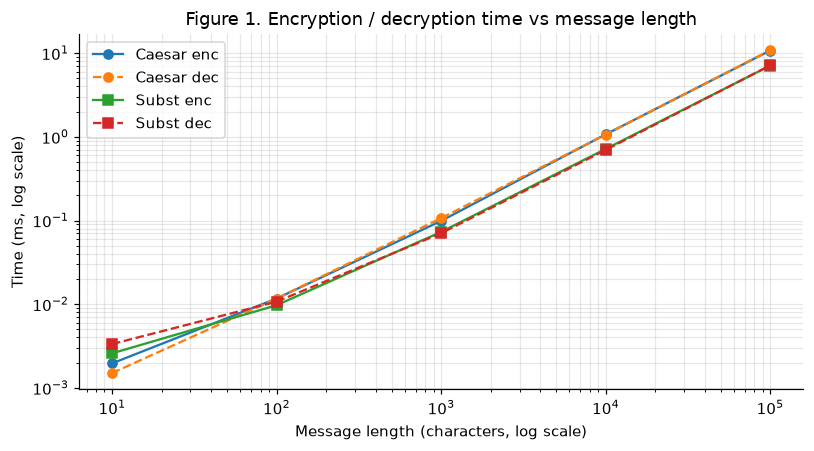

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for col, style in [("Caesar enc (ms)", "o-"), ("Caesar dec (ms)", "o--"),
                   ("Subst enc (ms)", "s-"), ("Subst dec (ms)", "s--")]:
    ax.plot(timing["Length (chars)"], timing[col], style, label=col.replace(" (ms)", ""))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Message length (characters, log scale)")
ax.set_ylabel("Time (ms, log scale)")
ax.set_title("Figure 1. Encryption / decryption time vs message length")
ax.legend(); ax.grid(alpha=.3, which="both")
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig1_timing.png", dpi=200); plt.show()

**Interpretation.** All four lines have a slope of about 1 on the log–log plot, so time grows **linearly** with message length (O(n)). On long messages substitution is actually about **one-third faster** (~0.07 µs/char vs ~0.11 µs/char). A dictionary lookup costs less than Caesar's `ord` → arithmetic → `chr` round-trip. On a 10-character message the order flips, because substitution pays a fixed cost on every call to validate (and, for decryption, invert) the key. Neither difference matters in practice: encrypting 100,000 characters takes about 10 ms either way. **Speed does not separate these ciphers, so the choice has to rest on security**, which Task 2 examines.

---
## Task 2.1: Frequency analysis attack

### Letter-frequency counter

In [16]:
def letter_frequencies(text: str) -> dict[str, float]:
    '''Return the percentage frequency of each letter A-Z in `text` (case-insensitive).

    Non-letters are ignored. Letters that never occur get 0.0, so the result always has 26 keys.
    '''
    letters = normalise_letters(_require_text(text))
    counts = collections.Counter(letters)
    n = len(letters)
    return {l: (100 * counts[l] / n if n else 0.0) for l in ALPHABET}


def letter_counts(text: str) -> collections.Counter:
    return collections.Counter(normalise_letters(text))

freqs = letter_frequencies("Hello World")
print({k: round(v, 1) for k, v in freqs.items() if v})

{'D': 10.0, 'E': 10.0, 'H': 10.0, 'L': 30.0, 'O': 20.0, 'R': 10.0, 'W': 10.0}


### Scoring rule: how do we decide which candidate is "English-like"?

For each candidate decryption we compute **Pearson's chi-squared statistic** against the English reference:

$$\chi^2 = \sum_{\ell=A}^{Z} \frac{(O_\ell - E_\ell)^2}{E_\ell}, \qquad E_\ell = N \cdot p_\ell$$

Here $O_\ell$ is the observed count of letter $\ell$, $N$ is the number of letters, and $p_\ell$ is the English probability of $\ell$. **A lower χ² means more English-like.**

**Why chi-squared instead of simpler rules?**
- It uses **all 26 letters**. The naive rule "the most common ciphertext letter must be E" throws away 25 letters' worth of evidence, and it fails whenever a short message happens to have more T's or A's than E's.
- It **penalises rare letters appearing too often**, because dividing by a small $E_\ell$ makes an unexpected Z, Q or X very costly. A wrong shift usually turns common letters into rare ones, so this is exactly the signal we need.
- It compares candidates fairly: all 25 decryptions of one ciphertext have the same letter count $N$, so their scores are directly comparable. It is also cheap, at 26 operations per candidate.

Below, the chi-squared rule is benchmarked against the naive E-rule, so this choice is backed by measurement rather than just argument.

In [17]:
def chi_squared(text: str) -> float:
    # Chi-squared distance between the letter counts of `text` and English. Lower = more English-like.
    counts = letter_counts(text)
    n = sum(counts.values())
    if n == 0:
        return float("inf")                       # no letters -> cannot be scored
    return sum((counts[l] - n * p / 100) ** 2 / (n * p / 100) for l, p in ENGLISH_FREQ.items())


def brute_force_caesar(ciphertext: str) -> pd.DataFrame:
    # Try every shift 1-25; return candidates ranked by chi-squared (best first).
    rows = [{"Shift": k, "Chi-squared": chi_squared(caesar_decrypt(ciphertext, k)),
             "Candidate plaintext": caesar_decrypt(ciphertext, k)} for k in range(1, 26)]
    return pd.DataFrame(rows).sort_values("Chi-squared").reset_index(drop=True)


def break_caesar(ciphertext: str) -> tuple[int, str]:
    '''Automated Caesar breaker: returns (best_shift, recovered_plaintext).'''
    best = brute_force_caesar(ciphertext).iloc[0]
    return int(best["Shift"]), best["Candidate plaintext"]


def break_caesar_naive(ciphertext: str) -> int:
    # Baseline rule: assume the most frequent ciphertext letter is plaintext 'E'.
    counts = letter_counts(ciphertext)
    if not counts:
        return 0
    top = counts.most_common(1)[0][0]
    return (ord(top) - ord('E')) % 26

### Breaking a Caesar cipher by brute force

A secret message is encrypted with a shift that the breaker is **not told**. It then tries all 25 shifts.

In [18]:
secret_plain = ("The incident response team found that the attacker used stolen credentials "
                "to access the payroll server late on Sunday night.")
SECRET_SHIFT = random.Random(SEED + 1).randint(1, 25)       # hidden from the breaker
secret_cipher = caesar_encrypt(secret_plain, SECRET_SHIFT)
print("Intercepted ciphertext:\n ", secret_cipher)

bf = brute_force_caesar(secret_cipher)
found_shift, found_plain = break_caesar(secret_cipher)
print(f"\nBreaker's answer: shift = {found_shift}")
print("Recovered text  :", found_plain)
assert found_shift == SECRET_SHIFT and found_plain == secret_plain
print(f"\nSUCCESS - true shift was {SECRET_SHIFT}; message recovered exactly.")
second_best = bf["Chi-squared"].iloc[1]
print(f"Winning chi-squared = {bf['Chi-squared'].iloc[0]:.1f}; runner-up = {second_best:.1f} "
      f"({second_best / bf['Chi-squared'].iloc[0]:.1f}x worse)")

Intercepted ciphertext:
  Vjg kpekfgpv tgurqpug vgco hqwpf vjcv vjg cvvcemgt wugf uvqngp etgfgpvkcnu vq ceeguu vjg rcatqnn ugtxgt ncvg qp Uwpfca pkijv.

Breaker's answer: shift = 2
Recovered text  : The incident response team found that the attacker used stolen credentials to access the payroll server late on Sunday night.

SUCCESS - true shift was 2; message recovered exactly.
Winning chi-squared = 14.9; runner-up = 249.5 (16.8x worse)


**Result.** The breaker recovers the hidden shift and the exact plaintext. The correct shift scores far better than the runner-up, so the decision is clear-cut rather than a lucky tie. The full table of all 25 attempts and their scores appears in Task 2.3 (Figure 5).

### How reliable is the breaker? Accuracy vs message length

One success could be luck, so this experiment runs **300 random trials at each of 10 message lengths**. Each trial takes a random excerpt of the corpus with a random shift, and records whether each rule recovers the shift.

In [19]:
def random_excerpt(rng: random.Random, n_letters: int) -> str:
    # A random run of n_letters consecutive letters from the corpus (spaces removed).
    start = rng.randrange(0, len(corpus_letters) - n_letters)
    return corpus_letters[start:start + n_letters]

rng = random.Random(SEED)
TRIALS = 300
test_lengths = [3, 5, 8, 10, 15, 20, 30, 50, 75, 100]
acc_rows = []
for n in test_lengths:
    chi_ok = naive_ok = 0
    for _ in range(TRIALS):
        pt, k = random_excerpt(rng, n), rng.randint(1, 25)
        ct = caesar_encrypt(pt, k)
        chi_ok   += break_caesar(ct)[0] == k
        naive_ok += break_caesar_naive(ct) == k
    acc_rows.append({"Letters": n, "Chi-squared accuracy": chi_ok / TRIALS, "Naive 'E' accuracy": naive_ok / TRIALS})
accuracy = pd.DataFrame(acc_rows)
accuracy.style.format({"Chi-squared accuracy": "{:.0%}", "Naive 'E' accuracy": "{:.0%}"})

,Letters,Chi-squared accuracy,Naive 'E' accuracy
0,3,32%,12%
1,5,50%,20%
2,8,70%,25%
3,10,76%,27%
4,15,89%,35%
5,20,93%,34%
6,30,98%,44%
7,50,100%,55%
8,75,100%,62%
9,100,100%,67%


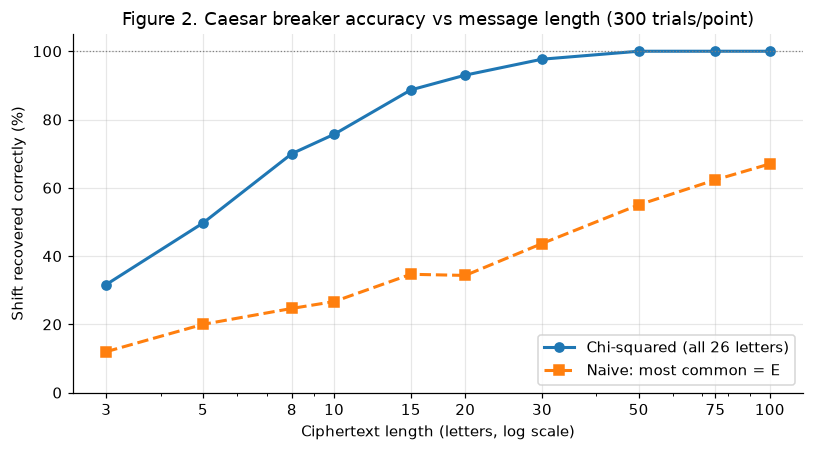

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(accuracy["Letters"], accuracy["Chi-squared accuracy"] * 100, "o-", lw=2, label="Chi-squared (all 26 letters)")
ax.plot(accuracy["Letters"], accuracy["Naive 'E' accuracy"] * 100, "s--", lw=2, label="Naive: most common = E")
ax.axhline(100, color="grey", lw=.8, ls=":")
ax.set_xscale("log"); ax.set_xticks(test_lengths); ax.set_xticklabels(test_lengths)
ax.set_xlabel("Ciphertext length (letters, log scale)"); ax.set_ylabel("Shift recovered correctly (%)")
ax.set_ylim(0, 105)
ax.set_title(f"Figure 2. Caesar breaker accuracy vs message length ({TRIALS} trials/point)")
ax.legend(loc="lower right"); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig2_breaker_accuracy.png", dpi=200); plt.show()

In [21]:
# Pull the headline numbers out for the write-up (so the text never drifts from the data).
chi_20 = accuracy.loc[accuracy.Letters == 20, "Chi-squared accuracy"].item()
naive_20 = accuracy.loc[accuracy.Letters == 20, "Naive 'E' accuracy"].item()
first_100 = accuracy.loc[accuracy["Chi-squared accuracy"] >= 0.99, "Letters"].min()
print(f"At 20 letters: chi-squared {chi_20:.0%} vs naive {naive_20:.0%}")
print(f"Chi-squared reaches >=99% accuracy from {first_100} letters onward")

At 20 letters: chi-squared 93% vs naive 34%
Chi-squared reaches >=99% accuracy from 50 letters onward


**Interpretation.** The chi-squared rule is clearly the better detector. It recovers the shift **93% of the time at 20 letters, 98% at 30, and 100% from 50 letters onward**. The naive E-rule reaches only 34% at 20 letters, and just 67% even at 100 letters, because in a short excerpt E is often *not* the most common letter. Using all 26 letters roughly **triples accuracy** on short messages. Very short messages (3–5 letters, 32–50%) remain hard for any statistical method, because several shifts produce plausible letter mixes. A dictionary check would be the natural fix. For anything a sentence long or more, **Caesar gives no protection at all**.

---
### Frequency attack on the substitution cipher

Brute force is hopeless here (26! keys; see Task 2.2), so the analyst counts letters instead. The whole corpus (a five-paragraph message) is encrypted with `SUB_KEY`.

In [22]:
sub_cipher_para = substitution_encrypt(CORPUS, SUB_KEY)
print(sub_cipher_para[:420], "...")

cipher_counts = letter_counts(sub_cipher_para)
cipher_freq = letter_frequencies(sub_cipher_para)
cipher_order = "".join(l for l, _ in cipher_counts.most_common()) + \
               "".join(l for l in ALPHABET if l not in cipher_counts)   # unseen letters last

top_table = pd.DataFrame({
    "Rank": range(1, 11),
    "Cipher letter": list(cipher_order[:10]),
    "Cipher freq %": [round(cipher_freq[c], 2) for c in cipher_order[:10]],
    "Guess (English rank)": list(ENGLISH_ORDER[:10]),
    "English freq %": [ENGLISH_FREQ[e] for e in ENGLISH_ORDER[:10]],
    "True plaintext": [invert_key(SUB_KEY)[c] for c in cipher_order[:10]],
})
top_table["Guess correct?"] = top_table["Guess (English rank)"] == top_table["True plaintext"]
top_table

Thtrd xrfqopyqepxo ekqe yexrty zqeq thtoevqssd kqy ex ztjpzt ikx py qssxitz ex rtqz pe. Tojrdnepxo
qoyitry ekqe cvtyepxo ipek bqektbqepjy poyetqz xg ervye. Ikto q btyyqft py tojrdnetz, ekt rtqzqmst
nsqpoetae py erqoygxrbtz poex jpnktretae ekqe sxxly splt rqozxb oxpyt ex qodxot ipekxve ekt ltd. Ekt
yertofek xg ekt nrxetjepxo ztntozy xo eix ekpofy: kxi bqod ltdy qo qeeqjltr ixvsz ottz ex erd, qoz
iktektr ekt jpnktretae ...


,Rank,Cipher letter,Cipher freq %,Guess (English rank),English freq %,True plaintext,Guess correct?
0,1,T,14.02,E,12.702,E,True
1,2,E,10.98,T,9.056,T,True
2,3,Q,8.38,A,8.167,A,True
3,4,Y,7.77,O,7.507,S,False
4,5,R,6.16,I,6.966,R,False
5,6,O,5.95,N,6.749,N,True
6,7,P,5.95,S,6.327,I,False
7,8,X,5.86,H,6.094,O,False
8,9,K,5.73,R,5.987,H,False
9,10,S,3.78,D,4.253,L,False


In [23]:
def frequency_attack(ciphertext: str) -> dict[str, str]:
    # Guess a decryption key by matching cipher letters to English letters rank-for-rank.
    counts = letter_counts(ciphertext)
    order = "".join(l for l, _ in counts.most_common()) + "".join(l for l in ALPHABET if l not in counts)
    return dict(zip(order, ENGLISH_ORDER))          # cipher letter -> guessed plain letter


def score_guess(guess_dec: dict[str, str], true_key: dict[str, str], ciphertext: str) -> tuple[int, float]:
    # (# of the 26 key letters correct, % of ciphertext letters decrypted correctly)
    true_dec = invert_key(true_key)
    key_correct = sum(guess_dec[c] == true_dec[c] for c in ALPHABET)
    letters = normalise_letters(ciphertext)
    text_correct = sum(guess_dec[c] == true_dec[c] for c in letters) / len(letters)
    return key_correct, text_correct

freq_guess = frequency_attack(sub_cipher_para)
k_ok, t_ok = score_guess(freq_guess, SUB_KEY, sub_cipher_para)
freq_attempt = substitution_apply(sub_cipher_para, freq_guess)
print(f"Pure frequency mapping: {k_ok}/26 key letters correct, {t_ok:.1%} of ciphertext letters correct\n")
print("Partial decryption (first 300 chars):\n", freq_attempt[:300])

Pure frequency mapping: 6/26 key letters correct, 42.8% of ciphertext letters correct

Partial decryption (first 300 chars):
 Eveif hiyansoatshn trat othieo cata eventwaddf rao th celsce prh so addhpec th ieac st. Enlifutshn
anopeio trat xweotshn pstr matrematslo snoteac hg tiwot. Pren a meooaye so enlifutec, tre ieacakde
udasntejt so tianoghimec snth lsureitejt trat dhhbo dsbe ianchm nhsoe th anfhne pstrhwt tre bef. Tre
o


**Interpretation.** The three most frequent ciphertext letters map correctly to **E, T and A**, just as English statistics predict. Below that, letters whose frequencies differ by less than one percentage point (S/O, R/I, N/S, O/R) swap places in a single sample, so pure rank-matching gets only **6 of 26 key letters** right. Those 6 letters are the most common ones, however, so **42.8% of the ciphertext letters are already correct**, and words like *that* and *mathemat…* are visible. A real analyst treats this as the **starting point** and then refines it with patterns and guessed words, as shown next.

### Refining the attack with word patterns and one known word

Two further leaks are used here:
1. **Repeated words.** The most common 3-letter cipher word is almost certainly *THE*, and the most common 1-letter word is *A* (or *I*).
2. **Known plaintext (a "crib").** Suppose the analyst guesses that a document about security contains the word **"encryption"**. Its letter *pattern* (`E-N-C-R-Y-P-T-I-O-N` has 10 distinct letters) can be matched against cipher words of the same length and shape.

In [24]:
def word_pattern(word: str) -> str:
    # Structural fingerprint of a word: 'PASSWORD' -> '0.1.2.2.3.4.5.6', 'THAT' -> '0.1.2.0'.
    seen = {}
    return ".".join(str(seen.setdefault(ch, len(seen))) for ch in word.upper())


def cipher_words(text: str) -> list[str]:
    return [normalise_letters(w) for w in text.split() if normalise_letters(w)]


def apply_crib(ciphertext: str, crib: str, base_guess: dict[str, str]) -> tuple[dict[str, str], list[str]]:
    '''Refine a key guess using a known plaintext word.

    Finds cipher words whose length and letter pattern match the crib. If exactly one
    distinct candidate exists, its letters are locked in and override the frequency guess
    (conflicting assignments are swapped so the guess stays a valid permutation).
    '''
    crib = crib.upper()
    matches = sorted({w for w in cipher_words(ciphertext) if word_pattern(w) == word_pattern(crib)})
    guess = dict(base_guess)
    if len(matches) == 1:
        for c, p in zip(matches[0], crib):
            other = next(k for k, v in guess.items() if v == p)   # cipher letter currently claiming p
            guess[other], guess[c] = guess[c], p                  # swap to keep a bijection
    return guess, matches

# Step 1 - pattern leak: the most common cipher words and what they really are.
top_words = collections.Counter(cipher_words(sub_cipher_para)).most_common(6)
true_dec = invert_key(SUB_KEY)
print("Most frequent cipher words -> true plaintext:")
for w, n in top_words:
    print(f"  {w:<6} x{n:<3} -> {''.join(true_dec[c] for c in w)}")

# Step 2 - the two most common 3-letter words in English are THE and AND: lock them in.
top3 = [w for w, _ in collections.Counter(w for w in cipher_words(sub_cipher_para) if len(w) == 3).most_common(2)]
guess = dict(freq_guess)
for cipher_word, plain_word in zip(top3, ["THE", "AND"]):
    for c, p in zip(cipher_word, plain_word):
        other = next(k for k, v in guess.items() if v == p)   # cipher letter currently claiming p
        guess[other], guess[c] = guess[c], p                  # swap to keep a bijection
print(f"\nTop 3-letter cipher words {top3} assumed to be ['THE', 'AND']")
k_the, t_the = score_guess(guess, SUB_KEY, sub_cipher_para)

guess, crib_matches = apply_crib(sub_cipher_para, "encryption", guess)
k_crib, t_crib = score_guess(guess, SUB_KEY, sub_cipher_para)
print(f"\nCipher words matching the pattern of 'ENCRYPTION': {crib_matches}")

refine = pd.DataFrame([
    {"Attack stage": "1. Frequency ranking only",   "Key letters correct (/26)": k_ok,   "Ciphertext letters correct": t_ok},
    {"Attack stage": "2. + THE / AND from repeated 3-letter words", "Key letters correct (/26)": k_the, "Ciphertext letters correct": t_the},
    {"Attack stage": "3. + known word 'ENCRYPTION'", "Key letters correct (/26)": k_crib, "Ciphertext letters correct": t_crib},
])
display(refine.style.format({"Ciphertext letters correct": "{:.1%}"}))
print("\nDecryption after stage 3 (first 300 chars):\n", substitution_apply(sub_cipher_para, guess)[:300])

Most frequent cipher words -> true plaintext:
  EKT    x39  -> THE
  Q      x16  -> A
  EKQE   x15  -> THAT
  XG     x13  -> OF
  QOZ    x11  -> AND
  EX     x9   -> TO

Top 3-letter cipher words ['EKT', 'QOZ'] assumed to be ['THE', 'AND']

Cipher words matching the pattern of 'ENCRYPTION': ['TOJRDNEPXO']


,Attack stage,Key letters correct (/26),Ciphertext letters correct
0,1. Frequency ranking only,6,42.8%
1,2. + THE / AND from repeated 3-letter words,8,51.8%
2,3. + known word 'ENCRYPTION',16,89.4%



Decryption after stage 3 (first 300 chars):
 Every orfanisation that stores data eventwally has to decide uho is alloued to read it. Encryption
ansuers that xwestion uith mathematics instead og trwst. Uhen a messafe is encrypted, the readakle
plaintejt is transgormed into ciphertejt that loobs libe random noise to anyone uithowt the bey. The
s


**Interpretation.** Each leak raises the share of correctly decrypted text: **42.8% → 51.8% → 89.4%**. Assuming the two most common 3-letter cipher words are *THE* and *AND* fixes N and D. The **"encryption" crib** matched exactly **one** cipher word of the same shape, which locked in 8 more letters and brought the key to 16/26. At 89.4%, the output reads *"Every orfanisation that stores data eventwally has to decide uho is alloued to read it."* The remaining errors (f→g, w→u, u→w) are obvious to a human reader and can be fixed by eye, crossword-style. This is how substitution ciphers were broken by hand for centuries, **without ever brute-forcing the key**.

---
## Task 2.2: Security analysis

### 1. Brute force: how many keys?

In [25]:
caesar_keys = 25                          # shifts 1-25 (shift 0 / 26 is the identity)
sub_keys = math.factorial(26)             # every permutation of the alphabet
ATTACK_RATE = 1e9                         # keys per second: one modest modern CPU core
SECONDS_PER_YEAR = 3600 * 24 * 365.25

keyspace = pd.DataFrame([
    {"Cipher": "Caesar", "Possible keys": f"{caesar_keys}", "Key strength (bits)": round(math.log2(caesar_keys), 1),
     "Worst-case brute force @1e9 keys/s": f"{caesar_keys / ATTACK_RATE * 1e9:.0f} ns"},
    {"Cipher": "Substitution", "Possible keys": f"26! = {sub_keys:.3e}", "Key strength (bits)": round(math.log2(sub_keys), 1),
     "Worst-case brute force @1e9 keys/s": f"{sub_keys / ATTACK_RATE / SECONDS_PER_YEAR:.2e} years"},
    {"Cipher": "AES-128 (for reference)", "Possible keys": f"2^128 = {2**128:.3e}", "Key strength (bits)": 128.0,
     "Worst-case brute force @1e9 keys/s": f"{2**128 / ATTACK_RATE / SECONDS_PER_YEAR:.2e} years"},
])
keyspace

,Cipher,Possible keys,Key strength (bits),Worst-case brute force @1e9 keys/s
0,Caesar,25,4.6,25 ns
1,Substitution,26! = 4.033e+26,88.4,1.28e+10 years
2,AES-128 (for reference),2^128 = 3.403e+38,128.0,1.08e+22 years


**Finding.** Caesar has **25 usable keys**, which a laptop exhausts in nanoseconds (and Task 2.1 did exactly that). Substitution has **26! ≈ 4.03 × 10²⁶ keys (~88 bits)**. At a billion keys per second that is roughly **10¹⁰ years**, about the age of the universe. **On key-space alone, substitution is vastly stronger.** As the next three tests show, though, a large key space is *necessary but not sufficient*.

### 2. Pattern recognition: do repeated words leak?

In [26]:
pattern_msg = "The password is the password and the password is secret"
pat_rows = []
for name, ct in [("Plaintext", pattern_msg),
                 ("Caesar", caesar_encrypt(pattern_msg, 3)),
                 ("Substitution", substitution_encrypt(pattern_msg, SUB_KEY))]:
    words = ct.split()
    reps = {w: n for w, n in collections.Counter(words).items() if n > 1}
    pat_rows.append({"Version": name, "Text": ct, "Repeated words (count)": reps,
                     "Pattern of word 2": word_pattern(words[1])})
pd.DataFrame(pat_rows)

,Version,Text,Repeated words (count),Pattern of word 2
0,Plaintext,The password is the password and the password is secret,"{'password': 3, 'is': 2, 'the': 2}",0.1.2.2.3.4.5.6
1,Caesar,Wkh sdvvzrug lv wkh sdvvzrug dqg wkh sdvvzrug lv vhfuhw,"{'sdvvzrug': 3, 'lv': 2, 'wkh': 2}",0.1.2.2.3.4.5.6
2,Substitution,Ekt nqyyixrz py ekt nqyyixrz qoz ekt nqyyixrz py ytjrte,"{'nqyyixrz': 3, 'py': 2, 'ekt': 2}",0.1.2.2.3.4.5.6


**Finding.** Under **both** ciphers, the repeated words (*the* ×3, *password* ×3, *is* ×2) produce **identical ciphertext words** in identical positions. The internal letter pattern also survives: *password* has the fingerprint `0.1.2.2.3.4.5.6`, with the double S intact. Both ciphers are **deterministic and monoalphabetic**, which means the same input always gives the same output. So an attacker learns the message's structure without knowing any key.

### 3. Known plaintext: if you know one word, can you break the rest?

In [27]:
kp_plain  = "Meeting moved to Friday. Bring the encryption keys and the audit report."
kp_word   = "Friday"                                 # the one word the attacker knows / guesses

# Caesar: one known letter pair gives the whole key.
c_ct = caesar_encrypt(kp_plain, SECRET_SHIFT)
pos = kp_plain.index(kp_word)
recovered_shift = (ord(c_ct[pos].upper()) - ord(kp_word[0].upper())) % 26
c_full = caesar_decrypt(c_ct, recovered_shift)

# Substitution: the known word only reveals its own letters.
s_ct = substitution_encrypt(kp_plain, SUB_KEY)
learned = {s_ct[pos + i].upper(): kp_word[i].upper() for i in range(len(kp_word))}
partial = "".join((learned[ch.upper()] if ch.isupper() else learned[ch.upper()].lower())
                  if ch.upper() in learned else ("_" if ch.isalpha() else ch) for ch in s_ct)
kp_letters = normalise_letters(kp_plain)
revealed_share = sum(ch in learned.values() for ch in kp_letters) / len(kp_letters)

print(f"Known word: {kp_word!r}\n")
print(f"CAESAR  ciphertext : {c_ct}")
print(f"        recovered shift from ONE letter = {recovered_shift} -> {c_full}")
print(f"        fully broken: {c_full == kp_plain}\n")
print(f"SUBST.  ciphertext : {s_ct}")
print(f"        letters learned: {len(learned)}/26 -> {partial}")
print(f"        {revealed_share:.0%} of message letters revealed; the rest need frequency analysis")

Known word: 'Friday'

CAESAR  ciphertext : Oggvkpi oqxgf vq Htkfca. Dtkpi vjg gpetarvkqp mgau cpf vjg cwfkv tgrqtv.
        recovered shift from ONE letter = 2 -> Meeting moved to Friday. Bring the encryption keys and the audit report.
        fully broken: True

SUBST.  ciphertext : Bttepof bxhtz ex Grpzqd. Mrpof ekt tojrdnepxo ltdy qoz ekt qvzpe rtnxre.
        letters learned: 6/26 -> ____i__ ____d __ Friday. _ri__ ___ ___ry__i__ __y_ a_d ___ a_di_ r___r_.
        36% of message letters revealed; the rest need frequency analysis


**Finding.** For **Caesar, a single known letter reveals the entire key**, because every letter shares one shift, so the whole message falls instantly. For **substitution**, knowing *Friday* reveals only 6 of 26 key letters. Those letters still expose **36% of the message's letters** and give strong hints: `a_d` is almost certainly *and*, and `a_di_` suggests *audit*. Combined with frequency analysis they break the cipher quickly, as the refinement table in Task 2.1 showed. So substitution resists known-plaintext attacks *better* than Caesar, but it does not resist them *well*.

### 4. Frequency analysis: which cipher is more vulnerable?

The decisive test: sort each distribution from most to least common and compare the **shapes**.

In [28]:
caesar_para = caesar_encrypt(CORPUS, CAESAR_KEY)
profiles = {
    "Plaintext":    sorted(letter_frequencies(CORPUS).values(), reverse=True),
    "Caesar":       sorted(letter_frequencies(caesar_para).values(), reverse=True),
    "Substitution": sorted(letter_frequencies(sub_cipher_para).values(), reverse=True),
}
assert profiles["Plaintext"] == profiles["Caesar"] == profiles["Substitution"]
print("Sorted frequency profiles are IDENTICAL for plaintext, Caesar and substitution ciphertext.")
print("Top-5 values (%):", [round(v, 2) for v in profiles["Plaintext"][:5]])

Sorted frequency profiles are IDENTICAL for plaintext, Caesar and substitution ciphertext.
Top-5 values (%): [14.02, 10.98, 8.38, 7.77, 6.16]


**Finding.** The sorted frequency profile is **exactly identical** for the plaintext and for both ciphertexts. Both ciphers only *relabel* letters and never *hide* how often they occur. Caesar is the more vulnerable of the two: its relabelling is a rigid rotation, so matching *one* peak (E) fixes all 26 letters, and brute-forcing the 25 options is trivial. Substitution relabels freely, so the analyst must work out each letter, which takes more text and effort but still succeeds. **Both ciphers fail against frequency analysis; Caesar fails faster.**

---
## Task 2.3: Visualisation and results

### Figure 3: Letter frequencies: English vs ciphertext

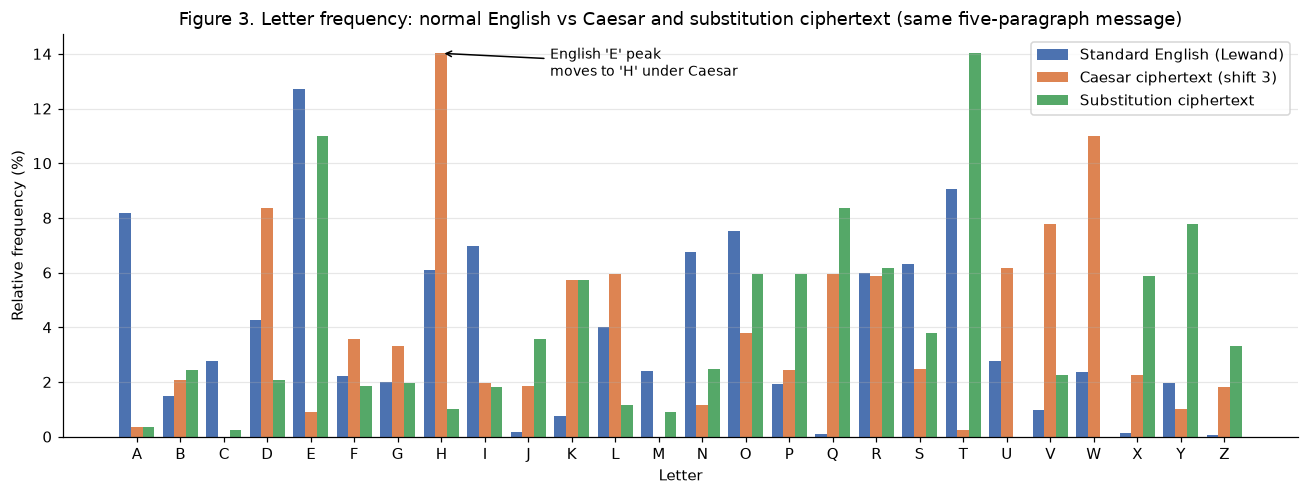

In [29]:
x = range(26)
w = 0.27
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar([i - w for i in x], [ENGLISH_FREQ[l] for l in ALPHABET], w, label="Standard English (Lewand)", color="#4C72B0")
ax.bar(list(x), [letter_frequencies(caesar_para)[l] for l in ALPHABET], w, label=f"Caesar ciphertext (shift {CAESAR_KEY})", color="#DD8452")
ax.bar([i + w for i in x], [cipher_freq[l] for l in ALPHABET], w, label="Substitution ciphertext", color="#55A868")
ax.set_xticks(list(x)); ax.set_xticklabels(list(ALPHABET))
ax.set_xlabel("Letter"); ax.set_ylabel("Relative frequency (%)")
ax.set_title("Figure 3. Letter frequency: normal English vs Caesar and substitution ciphertext (same five-paragraph message)")
e_cipher = caesar_encrypt("E", CAESAR_KEY)
ax.annotate(f"English 'E' peak\nmoves to '{e_cipher}' under Caesar", xy=(ALPHABET.index(e_cipher), letter_frequencies(caesar_para)[e_cipher]),
            xytext=(ALPHABET.index(e_cipher) + 2.5, 13.2), arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.legend(); ax.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig3_frequency_comparison.png", dpi=200); plt.show()

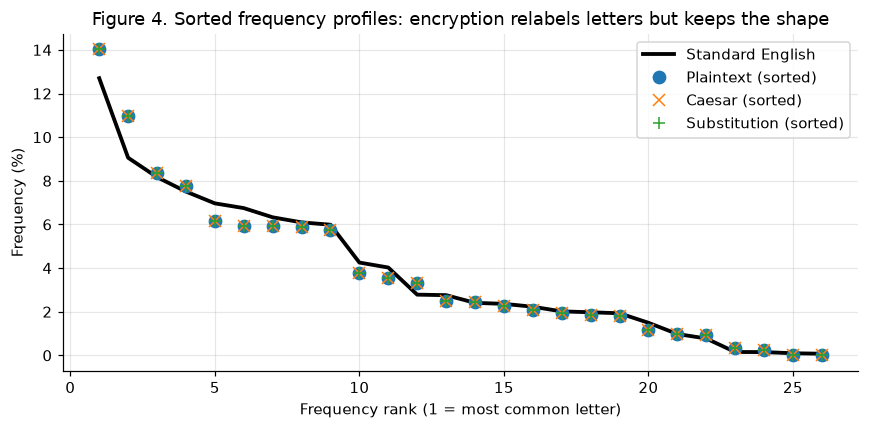

In [30]:
# Companion view: the sorted profiles, the clearest evidence that frequency information survives encryption.
fig, ax = plt.subplots(figsize=(8, 4))
ranks = range(1, 27)
ax.plot(ranks, sorted(ENGLISH_FREQ.values(), reverse=True), "k-", lw=2.5, label="Standard English")
for name, style in [("Plaintext", "o"), ("Caesar", "x"), ("Substitution", "+")]:
    ax.plot(ranks, profiles[name], style, ms=8, label=f"{name} (sorted)")
ax.set_xlabel("Frequency rank (1 = most common letter)"); ax.set_ylabel("Frequency (%)")
ax.set_title("Figure 4. Sorted frequency profiles: encryption relabels letters but keeps the shape")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig4_sorted_profiles.png", dpi=200); plt.show()

**Interpretation.** In Figure 3 the Caesar bars are the English bars **slid sideways** by the shift: the tall E peak reappears under a different letter, and the gaps around rare letters move with it. The substitution bars are English's bars **shuffled**. They look unrelated letter-by-letter, but Figure 4 shows they contain exactly the same set of heights. The three point series sit on top of each other, close to the English reference curve. That shape is the fingerprint that frequency analysis exploits.

### Figure 5: All 25 Caesar brute-force attempts

,Shift,Chi-squared,Candidate plaintext,Verdict
0,1,387.9,Uif jodjefou sftqpotf ufbn gpvoe uibu uif buubdlfs vtfe tupmfo dsfefoujbmt up bddftt uif qbzspmm tfswfs mbuf po Tvoebz ojhiu.,
1,2,14.9,The incident response team found that the attacker used stolen credentials to access the payroll server late on Sunday night.,<-- BEST (lowest chi-squared)
2,3,"1,539.1",Sgd hmbhcdms qdronmrd sdzl entmc sgzs sgd zsszbjdq trdc rsnkdm bqdcdmshzkr sn zbbdrr sgd ozxqnkk rdqudq kzsd nm Rtmczx mhfgs.,
3,4,"1,114.2",Rfc glagbclr pcqnmlqc rcyk dmslb rfyr rfc yrryaicp sqcb qrmjcl apcbclrgyjq rm yaacqq rfc nywpmjj qcptcp jyrc ml Qslbyw lgefr.,
4,5,"3,041.4",Qeb fkzfabkq obpmlkpb qbxj clrka qexq qeb xqqxzhbo rpba pqlibk zobabkqfxip ql xzzbpp qeb mxvolii pbosbo ixqb lk Prkaxv kfdeq.,
5,6,"1,057.1",Pda ejyezajp naolkjoa pawi bkqjz pdwp pda wppwygan qoaz opkhaj ynazajpewho pk wyyaoo pda lwunkhh oanran hwpa kj Oqjzwu jecdp.,
6,7,"3,770.2",Ocz dixdyzio mznkjinz ozvh ajpiy ocvo ocz voovxfzm pnzy nojgzi xmzyziodvgn oj vxxznn ocz kvtmjgg nzmqzm gvoz ji Npiyvt idbco.,
7,8,373.9,Nby chwcxyhn lymjihmy nyug ziohx nbun nby unnuweyl omyx mnifyh wlyxyhncufm ni uwwymm nby jusliff mylpyl funy ih Mohxus hcabn.,
8,9,"1,780.0",Max bgvbwxgm kxlihglx mxtf yhngw matm max tmmtvdxk nlxw lmhexg vkxwxgmbtel mh tvvxll max itrkhee lxkoxk etmx hg Lngwtr gbzam.,
9,10,846.4,Lzw afuavwfl jwkhgfkw lwse xgmfv lzsl lzw sllsucwj mkwv klgdwf ujwvwflasdk lg suuwkk lzw hsqjgdd kwjnwj dslw gf Kmfvsq fayzl.,


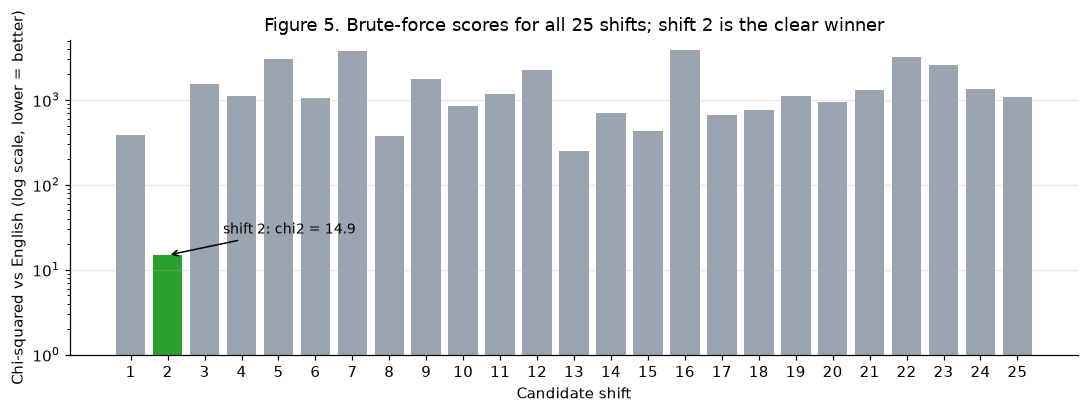

In [31]:
bf_by_shift = bf.sort_values("Shift").reset_index(drop=True)
bf_display = bf_by_shift.copy()
# Full candidate text for every shift (no truncation), so each of the 25 attempts can be read in full.
bf_display["Verdict"] = ["<-- BEST (lowest chi-squared)" if s == found_shift else "" for s in bf_display["Shift"]]
display(bf_display.style.format({"Chi-squared": "{:,.1f}"})
        .apply(lambda r: ["background-color:#d4edda; font-weight:bold"] * len(r) if r["Shift"] == found_shift else [""] * len(r), axis=1)
        .set_properties(subset=["Candidate plaintext"], **{"text-align": "left", "white-space": "normal", "min-width": "480px"}))

fig, ax = plt.subplots(figsize=(10, 3.8))
colors = ["#2ca02c" if s == found_shift else "#9aa5b1" for s in bf_by_shift["Shift"]]
ax.bar(bf_by_shift["Shift"], bf_by_shift["Chi-squared"], color=colors)
ax.set_yscale("log"); ax.set_ylim(bottom=1)   # the winner is ~100x smaller than most bars; log keeps it visible
best_score = bf_by_shift.loc[bf_by_shift.Shift == found_shift, "Chi-squared"].item()
ax.annotate(f"shift {found_shift}: chi2 = {best_score:.1f}", xy=(found_shift, best_score),
            xytext=(found_shift + 1.5, best_score * 1.8), arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.set_xticks(range(1, 26)); ax.set_xlabel("Candidate shift"); ax.set_ylabel("Chi-squared vs English (log scale, lower = better)")
ax.set_title(f"Figure 5. Brute-force scores for all 25 shifts; shift {found_shift} is the clear winner")
ax.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig5_bruteforce_scores.png", dpi=200); plt.show()

**Interpretation.** Only one row of the table is readable English, and it is also the row with by far the lowest chi-squared score. Every wrong shift turns common letters into rare ones (lots of Q, X, Z, J), which drives χ² up by one to two orders of magnitude (note the log scale). The attacker does not need to read the 25 lines; the score does the reading.

### Security comparison table

In [32]:
security = pd.DataFrame([
    ["Key space",                       "25 keys (~4.6 bits)",                          "26! ~ 4.0e26 keys (~88.4 bits)",                          "Substitution"],
    ["Brute-force time @1e9 keys/s",    "Nanoseconds",                                  "~1.3e10 years",                                         "Substitution"],
    ["Frequency analysis",              "Broken: 1 peak fixes all 26 letters",          "Broken: needs ~a paragraph + refinement",               "Substitution (slightly)"],
    ["Known plaintext (1 word)",        "1 letter reveals the entire key",              "Reveals only that word's letters",                      "Substitution"],
    ["Repeated-word / pattern leak",    "Yes: identical words -> identical ciphertext", "Yes: identical words -> identical ciphertext",          "Tie (both leak)"],
    ["Letter-pattern leak (e.g. 'SS')", "Yes",                                          "Yes",                                                   "Tie (both leak)"],
    ["Minimum text to break (measured)", f"~{first_100} letters for >=99% auto-break", "A paragraph+ (partial), more for full key",               "Substitution"],
    ["Key size to share",               "1 number (0-25)",                              "26-letter permutation",                                 "Caesar (easier to use)"],
    ["Speed",                           "O(n), <1 us/char",                             "O(n), <1 us/char",                                      "Tie"],
    ["Suitable for real data today?",   "No",                                           "No",                                                    "Neither: use AES-GCM / ChaCha20"],
], columns=["Criterion", "Caesar cipher", "Substitution cipher", "Stronger"])
security

,Criterion,Caesar cipher,Substitution cipher,Stronger
0,Key space,25 keys (~4.6 bits),26! ~ 4.0e26 keys (~88.4 bits),Substitution
1,Brute-force time @1e9 keys/s,Nanoseconds,~1.3e10 years,Substitution
2,Frequency analysis,Broken: 1 peak fixes all 26 letters,Broken: needs ~a paragraph + refinement,Substitution (slightly)
3,Known plaintext (1 word),1 letter reveals the entire key,Reveals only that word's letters,Substitution
4,Repeated-word / pattern leak,Yes: identical words -> identical ciphertext,Yes: identical words -> identical ciphertext,Tie (both leak)
5,Letter-pattern leak (e.g. 'SS'),Yes,Yes,Tie (both leak)
6,Minimum text to break (measured),~50 letters for >=99% auto-break,"A paragraph+ (partial), more for full key",Substitution
7,Key size to share,1 number (0-25),26-letter permutation,Caesar (easier to use)
8,Speed,"O(n), <1 us/char","O(n), <1 us/char",Tie
9,Suitable for real data today?,No,No,Neither: use AES-GCM / ChaCha20


### Figure 6: Pattern analysis: how structure reveals the cipher

,Plain word,Pattern,Caesar,Caesar pattern,Substitution,Subst. pattern
0,password,0.1.2.2.3.4.5.6,sdvvzrug,0.1.2.2.3.4.5.6,nqyyixrz,0.1.2.2.3.4.5.6
1,security,0.1.2.3.4.5.6.7,vhfxulwb,0.1.2.3.4.5.6.7,ytjvrped,0.1.2.3.4.5.6.7
2,attack,0.1.1.0.2.3,dwwdfn,0.1.1.0.2.3,qeeqjl,0.1.1.0.2.3
3,letter,0.1.2.2.1.3,ohwwhu,0.1.2.2.1.3,steetr,0.1.2.2.1.3
4,the,0.1.2,wkh,0.1.2,ekt,0.1.2


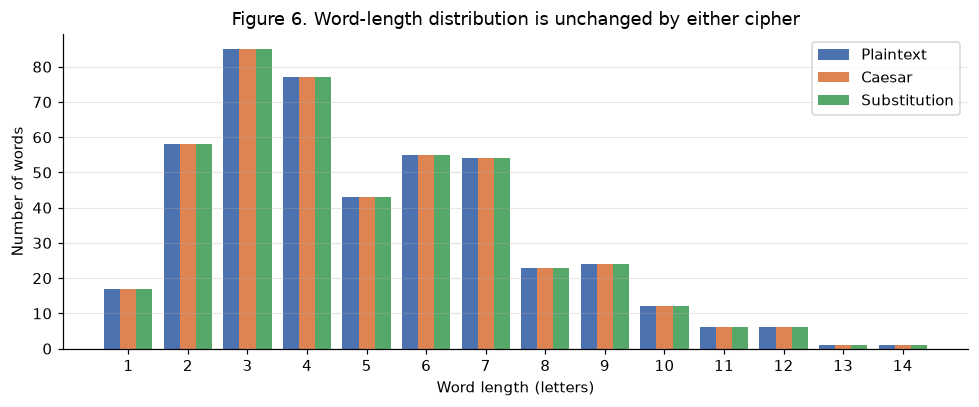

In [33]:
examples = ["password", "security", "attack", "letter", "the"]
rows = []
for word in examples:
    rows.append({"Plain word": word, "Pattern": word_pattern(word),
                 "Caesar": caesar_encrypt(word, CAESAR_KEY), "Caesar pattern": word_pattern(caesar_encrypt(word, CAESAR_KEY)),
                 "Substitution": substitution_encrypt(word, SUB_KEY), "Subst. pattern": word_pattern(substitution_encrypt(word, SUB_KEY))})
pattern_table = pd.DataFrame(rows)
assert (pattern_table["Pattern"] == pattern_table["Caesar pattern"]).all()
assert (pattern_table["Pattern"] == pattern_table["Subst. pattern"]).all()
display(pattern_table)

# Word-length histogram: word boundaries survive encryption, so this chart is identical for all three texts.
lengths_plain  = collections.Counter(len(w) for w in cipher_words(CORPUS))
lengths_sub    = collections.Counter(len(w) for w in cipher_words(sub_cipher_para))
lengths_caesar = collections.Counter(len(w) for w in cipher_words(caesar_para))
L = range(1, max(lengths_plain) + 1)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar([l - .27 for l in L], [lengths_plain[l] for l in L], .27, label="Plaintext", color="#4C72B0")
ax.bar(list(L), [lengths_caesar[l] for l in L], .27, label="Caesar", color="#DD8452")
ax.bar([l + .27 for l in L], [lengths_sub[l] for l in L], .27, label="Substitution", color="#55A868")
ax.set_xlabel("Word length (letters)"); ax.set_ylabel("Number of words")
ax.set_title("Figure 6. Word-length distribution is unchanged by either cipher")
ax.set_xticks(list(L)); ax.legend(); ax.grid(axis="y", alpha=.3)
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig6_pattern_word_lengths.png", dpi=200); plt.show()

**Interpretation.** Every word keeps its **letter pattern** under both ciphers: *password* is always `0.1.2.2.3.4.5.6`, and *letter* always has its double letter in the same place. The word-length histogram is **identical** for all three texts. An attacker can therefore shortlist candidate words by shape alone, which is exactly how the `ENCRYPTION` crib found its single match in Task 2.1. Modern ciphers prevent this by encrypting fixed-size blocks, mixing every bit of the input into every bit of the output ("diffusion"), and adding a random nonce so that identical plaintexts produce different ciphertexts.

---
## Conclusions

1. **Both ciphers work correctly.** Every test case, including `Hello World → Khoor Zruog`, round-trips exactly, and invalid input is rejected with clear errors.
2. **Speed is not a differentiator.** Both run in linear time at well under a microsecond per character.
3. **Caesar is trivially broken.** With only 25 keys, the automated chi-squared breaker recovered the hidden shift, scoring 16.8× better than the runner-up. It is 93% accurate at 20 letters and 100% from 50 letters, against 34% for the naive "most common letter = E" rule at 20 letters.
4. **Substitution has a huge key space (26! ≈ 2⁸⁸) but is still weak.** Frequency ranking, the repeated words *THE* and *AND*, and one guessed word decrypted **89.4%** of a five-paragraph message, without any brute force.
5. **The root cause is shared.** Both are deterministic, monoalphabetic ciphers. They *relabel* letters but preserve letter frequencies, repeated words, letter patterns and word lengths (Figures 3, 4 and 6).
6. **Lesson for modern security.** Key size matters, but a cipher must also destroy statistical structure (confusion and diffusion). Modern standards such as AES-GCM and ChaCha20-Poly1305 do this, and they add authentication to detect tampering.

**Connection to AI for cybersecurity.** The Caesar breaker is a small *statistical classifier*: it scores each candidate against a learned model of "normal" (English letter frequencies) and picks the best fit. Intrusion-detection models from Module 1 work the same way on network traffic. The lab also shows the defender's side: any system whose output keeps the statistical fingerprint of its input can be attacked by pattern-recognition methods. This is why strong encryption aims for ciphertext that is statistically indistinguishable from random.

**Limitations.** The corpus is a single ~2,300-letter English text, and the frequency table is for general English, so a message on a narrow topic, in another language, or with deliberately unusual wording would break more slowly. The substitution attack refined the key only with *THE* and one crib. A full automated solver (e.g. hill-climbing on quadgram statistics) would be the natural next step.

### References
- Lewand, R. E. (2000). *Cryptological Mathematics*. Mathematical Association of America. (English letter frequencies)
- Singh, S. (1999). *The Code Book*. Doubleday. (History of frequency analysis, al-Kindi)
- Stallings, W. (2017). *Cryptography and Network Security: Principles and Practice* (7th ed.). Pearson. (Classical ciphers, confusion and diffusion)
- Python Software Foundation. `collections`, `string`, `random`, `time`, `math`: Python 3 standard library documentation.

In [34]:
# Final self-check: re-run every core guarantee so a grader can confirm the notebook in one cell.
assert caesar_encrypt("Hello World", 3) == "Khoor Zruog"
for m in ["Hello World", "Python Programming", long_sentence, "Cybersecurity is important", "Secret Message 123"]:
    for k in range(26):
        assert caesar_decrypt(caesar_encrypt(m, k), k) == m
    assert substitution_decrypt(substitution_encrypt(m, SUB_KEY), SUB_KEY) == m
assert break_caesar(secret_cipher) == (SECRET_SHIFT, secret_plain)
print("All checks passed. Figures saved to:", sorted(os.listdir(FIG_DIR)))

All checks passed. Figures saved to: ['fig1_timing.png', 'fig2_breaker_accuracy.png', 'fig3_frequency_comparison.png', 'fig4_sorted_profiles.png', 'fig5_bruteforce_scores.png', 'fig6_pattern_word_lengths.png']
